# Demo: Beamforming and Network Response Function

> **Colab note:** This notebook is designed to run on **Google Colab**. The first code cell installs dependencies. [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amtseismo/EPS164/blob/main/demos/08b_plot_pdf_example.ipynb)

This example shows how to calculate the network response function and locate 
the tremor associated with the eruption at the Piton de la Fournaise on 
December 21, 2021.

One hour of seismic data from 17 stations is processed, starting at 23:35 UTC 
on December 21, 2021. The data is processed in 6 windows and the last window,
when the tremor signal is strongest, is selected for plotting the likelihood 
function.

Figures, from top to bottom:
    
#. Seismic waveforms from station FOR, closest to the tremor 
#. Spectral width, between 0.5Hz and 10Hz
#. Average spectral width between 0.5Hz to 5Hz
#. Network response function
#. Likelihood location function, map view
#. Likelihood location function, longitudinal cross-section
#. Likelihood location function, latitudinal cross-section
#. Unshifted cross-correlation envelopes (obtained before calculating the beam)
#. Shifted cross-correlation envelopes (corresponding to the maximum of the beam)


In [ ]:
# Install dependencies (for Google Colab or missing packages)
import sys

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running in local environment")

# Install required packages if needed
required_packages = {
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'covseisnet': 'covseisnet',
    'obspy': 'obspy'
}

missing_packages = []
for package, pip_name in required_packages.items():
    try:
        __import__(package)
        print(f"✓ {package} is already installed")
    except ImportError:
        missing_packages.append(pip_name)
        print(f"✗ {package} not found")

if missing_packages:
    print(f"\nInstalling missing packages: {', '.join(missing_packages)}")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing_packages)
    print("✓ Installation complete!")
else:
    print("\n✓ All required packages are installed!")

In [2]:
import covseisnet as csn
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import matplotlib.colors as mcolors
from matplotlib.colors import LightSource
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import numpy as np
import scipy.interpolate

# # download seismic data near using the RESIF Seismic data portal
client = Client("http://ws.ipgp.fr")
duration_sec = 60 * 60  # length of stream to be processed, in seconds
t = UTCDateTime("2021-12-21T23:35:00.00")
list_stations = [
    "BON",
    "BOR",
    "CRA",
    "CSS",
    "DSO",
    "ENO",
    "FJS",
    "FOR",
    "FRE",
    "GBS",
    "GPN",
    "GPS",
    "HDL",
    "HIM",
    "PHR",
    "PRA",
    "PVD",
    "RVA",
    "SNE",
]
stream = csn.arraystream.ArrayStream()
for sta in list_stations:

    print(f"Downloading station: {sta}")

    try:

        st = client.get_waveforms(
            "PF",
            sta,
            "*",
            "*HZ",
            t,
            t + duration_sec,
        )

        stream.append(st[0])

        print("  -> SUCCESS")

    except Exception as e:

        print(f"  -> FAILED : {e}")

# decimate data to 25Hz
stream.decimate(4)

# download metadata
inv = client.get_stations(
    network="PF", location="*", channel="*HZ", starttime=t, endtime=t + duration_sec
)

  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS
  -> SUCCESS


In [3]:
# Settings
# --------
traveltime_filepath = "/tt_sta/"  # path to traveltime grids


# frequency limits for filtering (depends on the target signal)
low_pass = 0.5
high_pass = 10.0

# optimized for VT earthquakes
# window_duration_sec = 12
# average = 20

# optimized for tremors
window_duration_sec = 60
average = 30

overlap = 0.5
sampling_rate = stream[
    0
].stats.sampling_rate  # assumes all streams have the same sampling rate
preproc_spectral_secs = window_duration_sec * average * overlap
sigma = 20  # Correlation Smoothing

i_win = 5  # choose the 5th window for plotting likelihood


# grid extent Longitude: 55.67° to 55.81° (145 points), Latitude: -21.3° to -21.2° (110 points)
lon_min = 55.67
lon_max = 55.81
lat_min = -21.3
lat_max = -21.2
depth_min = -2.6  # edifice summit (km)
depth_max = 3.0  # max depth of traveltime grids (km)

In [4]:
## merge traces to have one trace per station
stream.merge(method=1, fill_value="interpolate", interpolation_samples=-1)

## synchronize traces in the stream
stream = stream.synchronize(t, duration_sec, method="linear")

## filtering
stream.detrend(type="demean")
stream.detrend(type="linear")
stream.filter(type="bandpass", freqmin=low_pass, freqmax=high_pass)

# choose waveform from channel HHZ of station OGDF for plotting
trace_plot = stream.select(station="FOR", channel="HHZ")[0].data

## Preprocess
stream.preprocess(
    domain="spectral", method="onebit", window_duration_sec=preproc_spectral_secs
)
stream.trim(t, t + duration_sec)  # preprocessing can add artifacts to ends

/Applications/anaconda3/envs/covenv/lib/python3.12/site-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (10.0) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)


19 Trace(s) in Stream:
PF.BON.00.HHZ | 2021-12-21T23:35:00.000000Z - 2021-12-22T00:34:59.950000Z | 20.0 Hz, 72000 samples
PF.BOR.00.EHZ | 2021-12-21T23:35:00.000000Z - 2021-12-22T00:34:59.950000Z | 20.0 Hz, 72000 samples
PF.CRA.00.HHZ | 2021-12-21T23:35:00.000000Z - 2021-12-22T00:34:59.950000Z | 20.0 Hz, 72000 samples
PF.CSS.00.HHZ | 2021-12-21T23:35:00.000000Z - 2021-12-22T00:34:59.950000Z | 20.0 Hz, 72000 samples
PF.DSO.00.HHZ | 2021-12-21T23:35:00.000000Z - 2021-12-22T00:34:59.950000Z | 20.0 Hz, 72000 samples
PF.ENO.90.EHZ | 2021-12-21T23:35:00.000000Z - 2021-12-22T00:34:59.950000Z | 20.0 Hz, 72000 samples
PF.FJS.00.HHZ | 2021-12-21T23:35:00.000000Z - 2021-12-22T00:34:59.950000Z | 20.0 Hz, 72000 samples
PF.FOR.00.HHZ | 2021-12-21T23:35:00.000000Z - 2021-12-22T00:34:59.950000Z | 20.0 Hz, 72000 samples
PF.FRE.00.HHZ | 2021-12-21T23:35:00.000000Z - 2021-12-22T00:34:59.950000Z | 20.0 Hz, 72000 samples
PF.GBS.00.HHZ | 2021-12-21T23:35:00.000000Z - 2021-12-22T00:34:59.950000Z | 20.0 Hz, 7

In [5]:
# Calculate coherence
# -------------------


times, frequencies, covariances = csn.covariancematrix.calculate(
    stream, window_duration_sec, average
)


# Spectral width
spectral_width = covariances.coherence(kind="spectral_width")

# Average spectral width between 0.5Hz and 5Hz
i_freq_low = round(0.5 * spectral_width.shape[1] / sampling_rate)
i_freq_high = round(5 * spectral_width.shape[1] / sampling_rate)
spectral_width_average = np.mean(spectral_width[:, i_freq_low:i_freq_high], axis=1)

In [6]:
# Eigenvector decomposition - covariance matrix filtered by the 1st eigenvector to show the dominant source
covariance_1st = covariances.eigenvectors(covariance=True, rank=0)

# Extract cross-correlations
lags, correlation = csn.correlationmatrix.cross_correlation(
    covariance_1st, sampling_rate
)

# load traveltime grids from file
PdF_traveltimes = csn.traveltime.TravelTime(stream, traveltime_filepath)

# Initiate beam object and set geographical extent of grid
nwin = correlation.nwin()  # number of time windows
PdF_beam = csn.beam.Beam(nwin, PdF_traveltimes)
PdF_beam.set_extent(lon_min, lon_max, lat_min, lat_max, depth_min, depth_max)

# Loop through all windows and calculate likelihood and nrf
for i in range(0, nwin):
    print("Processing window", i + 1, "of", nwin)

    correl = correlation[i]

    # Filter correlation
    correl = correl.bandpass(low_pass, high_pass, sampling_rate)

    # Smooth correlation
    correl = correl.hilbert_envelope()
    correl = correl.smooth(sigma=sigma)  # default sigma is 5

    PdF_beam.calculate_likelihood(correl, sampling_rate, i)
    PdF_beam.calculate_nrf(i)

    beam_max = PdF_beam.max_likelihood(i)
    print(
        "Maximum likelihood at",
        round(beam_max[0], 4),
        "\N{DEGREE SIGN},",
        round(beam_max[1], 4),
        "\N{DEGREE SIGN},",
        round(beam_max[2], 1),
        "km",
    )

Processing window 1 of 6
Maximum likelihood at 55.6961 °, -21.2555 °, -2.6 km
Processing window 2 of 6
Maximum likelihood at 55.7067 °, -21.2764 °, -2.6 km
Processing window 3 of 6
Maximum likelihood at 55.6999 °, -21.2609 °, -2.6 km
Processing window 4 of 6
Maximum likelihood at 55.6999 °, -21.2609 °, -2.6 km
Processing window 5 of 6
Maximum likelihood at 55.7106 °, -21.26 °, -2.6 km
Processing window 6 of 6
Maximum likelihood at 55.7057 °, -21.2664 °, -2.6 km


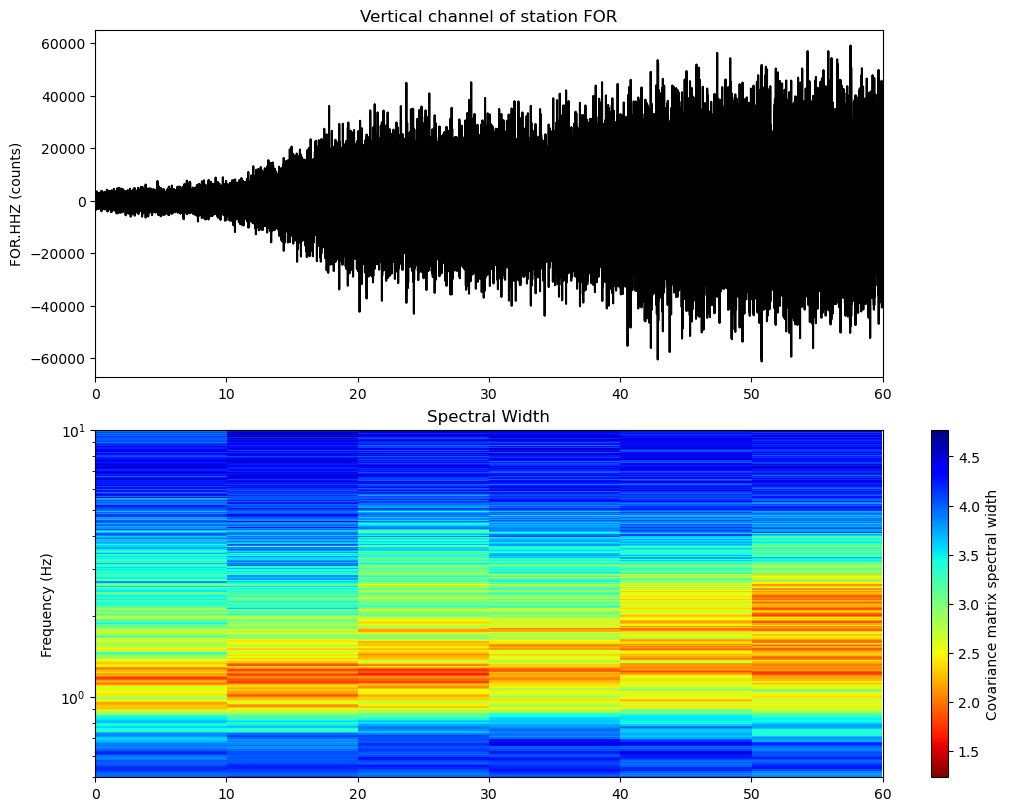

In [13]:
# plot nrf and spectral width and waveforms from closest station
duration_min = duration_sec / 60
fig, ax = plt.subplots(2, constrained_layout=True, figsize=(10, 8))  # stretched plot

ax[0].plot(np.linspace(0, duration_min, len(trace_plot)), trace_plot, "k")
ax[0].set_title("Vertical channel of station FOR")
ax[0].set_ylabel("FOR.HHZ (counts)")
ax[0].set_xlim([0, duration_min])

img = ax[1].imshow(
    spectral_width.T,
    origin="lower",
    cmap="jet_r",
    interpolation="none",
    extent=[0, duration_sec / 60, 0, sampling_rate],
    aspect="auto",
)
ax[1].set_ylim(
    [0.5, stream[0].stats.sampling_rate / 2]
)  # hide microseismic background noise below 0.5Hz
ax[1].set_ylabel("Frequency (Hz)")
ax[1].set_yscale("log")
ax[1].set_title("Spectral Width")
plt.colorbar(img, ax=ax[1]).set_label("Covariance matrix spectral width")



In [12]:
# extract max likelihood position
beam_max = PdF_beam.max_likelihood(i_win)
x_max = beam_max[0]
y_max = beam_max[1]
z_max = beam_max[2]

# Choose the last window for plotting likelihood
likelihood_xyz = PdF_beam.likelihood[i_win, :, :, :]

# Take slices at point of max likelihood
i_max, j_max, k_max = np.unravel_index(likelihood_xyz.argmax(), likelihood_xyz.shape)
likelihood_xy = likelihood_xyz[:, :, k_max]
likelihood_xz = likelihood_xyz[:, j_max]
likelihood_yz = likelihood_xyz[i_max]

# Normalize likelihood between 0 and 1
likelihood_xy = (likelihood_xy - likelihood_xy.min()) / (
    likelihood_xy.max() - likelihood_xy.min()
)
likelihood_xz = (likelihood_xz - likelihood_xz.min()) / (
    likelihood_xz.max() - likelihood_xz.min()
)
likelihood_yz = (likelihood_yz - likelihood_yz.min()) / (
    likelihood_yz.max() - likelihood_yz.min()
)


# create dictionary of station metadata from station xml
net = {"lat": [], "lon": []}
for tr in stream:
    inv_sel = inv.select(station=tr.stats.station)
    net["lat"].append(inv_sel[0][0].latitude)
    net["lon"].append(inv_sel[0][0].longitude)

# create custom discrete colormap for likelihood
low = 4
levels = 12
n_colours = 16  # number of discrete colours to split colourbar into
custom_cmap = plt.cm.get_cmap("RdYlBu_r")(np.linspace(0, 1, levels))
for i in range(low):
    custom_cmap[i, :] = [1, 1, 1, 1]
for i in range(1, levels):
    custom_cmap[i, -1] = np.sqrt(i / levels)
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "RdYlBu_r", custom_cmap, N=n_colours
)




/var/folders/9r/16pd0qn977z9j6s9qrqp6drm0000gq/T/ipykernel_86829/1439338867.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_cmap = plt.cm.get_cmap("RdYlBu_r")(np.linspace(0, 1, levels))


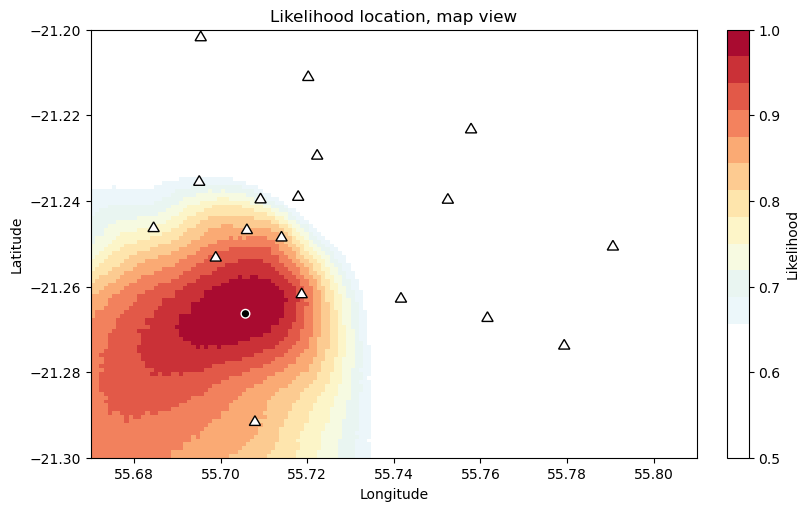

In [10]:
# plot map view
fig, ax = plt.subplots(1, constrained_layout=True, figsize=(8, 5), dpi=100)
img_xy = ax.imshow(
    likelihood_xy.T,
    interpolation="none",
    origin="lower",
    cmap=custom_cmap,
    aspect="auto",
    extent=[lon_min, lon_max, lat_min, lat_max],
    vmin=0.5,
)

ax.add_patch(
    plt.Circle((x_max, y_max), facecolor="black", edgecolor="white", radius=0.001)
)  # plot max likelihood position
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Likelihood location, map view")
for x, y in zip(net["lon"], net["lat"]):  # plot stations
    triangle = RegularPolygon(
        (x, y), facecolor="white", edgecolor="black", numVertices=3, radius=0.0015
    )
    ax.add_patch(triangle)
plt.colorbar(img_xy).set_label("Likelihood")

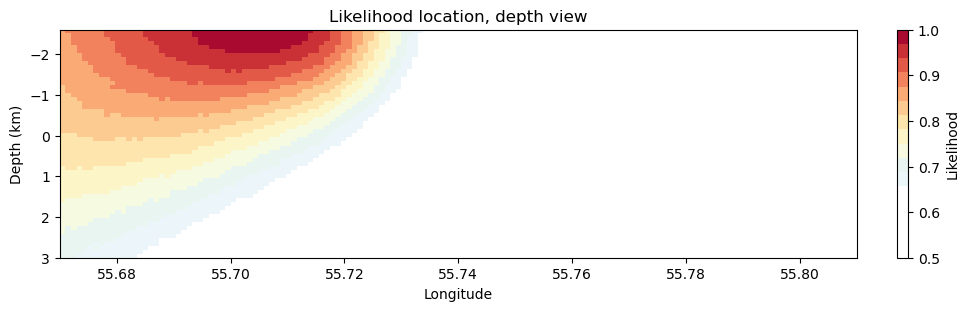

In [11]:
# plot depth views
fig, ax = plt.subplots(1, constrained_layout=True, figsize=(9.6, 3), dpi=100)
img_xz = ax.imshow(
    likelihood_xz.T,
    interpolation="none",
    origin="upper",
    cmap=custom_cmap,
    aspect="auto",
    extent=[lon_min, lon_max, depth_max, depth_min],
    vmin=0.5,
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Depth (km)")
ax.set_title("Likelihood location, depth view")
plt.colorbar(img_xz).set_label("Likelihood")